<a href="https://colab.research.google.com/github/M-Mag25/Group-Work-Project-1-/blob/main/Project_1_portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Real-World Evidence (RWE) Analysis with National Health and Nutrition Examination Survey (NHANES) Data: Hypertension Treatment Outcomes

**Portfolio Project 1: Clinical Data Analyst**


 Objective


Analyze the comparative effectiveness of hypertension medications using NHANES data, demonstrating skills in:
 - Real-world data cleaning & management
 - Propensity score matching for confounding adjustment
- Survival analysis with Kaplan-Meier curves
- Clear communication of observational study limitations


#1. Setup & Data Loading
 Install necessary packages

In [7]:
!pip install pandas numpy matplotlib seaborn lifelines scikit-learn -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from lifelines import KaplanMeierFitter, CoxPHFitter
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Packages loaded successfully!")

# %%
# Load NHANES data (2017-2020 pre-pandemic)
# Note: In a real project, you'd download from CDC website
# For this demo, we'll simulate realistic NHANES-like data

# Generate synthetic NHANES-like data
np.random.seed(42)
n = 5000

# Simulate realistic data
data = pd.DataFrame({
    'SEQN': range(100000, 100000 + n),
    'RIAGENDR': np.random.choice([1, 2], n, p=[0.48, 0.52]),  # 1=M, 2=F
    'RIDAGEYR': np.random.normal(55, 15, n).clip(18, 80),
    'RIDRETH1': np.random.choice([1, 2, 3, 4, 5], n, p=[0.3, 0.3, 0.2, 0.1, 0.1]),
    'BMXBMI': np.random.normal(28, 6, n).clip(18, 45),
    'BPXSY1': np.random.normal(140, 20, n),  # Systolic BP
    'BPXDI1': np.random.normal(85, 15, n),   # Diastolic BP
    'LBDHDD': np.random.normal(50, 15, n),   # HDL cholesterol
    'LBXTC': np.random.normal(200, 40, n),   # Total cholesterol
    'DIQ010': np.random.choice([1, 2, 9], n, p=[0.15, 0.84, 0.01]),  # Diabetes
    'SMQ040': np.random.choice([1, 2, 3, 7, 9], n, p=[0.2, 0.3, 0.2, 0.29, 0.01]),  # Smoking
})

# Simulate treatment assignment (ACE inhibitors vs ARBs)
# Let's create some realistic confounding
ace_prob = 1 / (1 + np.exp(-(0.3*(data['RIDAGEYR']-55)/10 +
                           0.2*(data['BMXBMI']-30)/5 -
                           0.1*(data['LBXTC']-200)/40)))

data['TREATMENT'] = np.random.binomial(1, ace_prob)
data['TREATMENT_NAME'] = data['TREATMENT'].map({0: 'ARB', 1: 'ACE Inhibitor'})

# Simulate cardiovascular events (time-to-event)
# ARBs have slightly better outcomes in our simulation
baseline_hazard = 0.001
time_to_event = np.random.exponential(1/(baseline_hazard *
                                         (1.3 - 0.2*data['TREATMENT'] +
                                          0.01*(data['BPXSY1']-140) +
                                          0.02*(data['BMXBMI']-30))))

data['TIME_TO_EVENT'] = time_to_event.clip(0, 60)  # 60 months max
data['EVENT'] = (time_to_event < 60).astype(int)  # Event if occurs within 60 months

print(" Synthetic NHANES-like data created!")
print(f"Dataset shape: {data.shape}")
print(f"\nTreatment distribution:")
print(data['TREATMENT_NAME'].value_counts())
print(f"\nEvent rate: {data['EVENT'].mean():.2%}")

✅ Packages loaded successfully!
 Synthetic NHANES-like data created!
Dataset shape: (5000, 15)

Treatment distribution:
TREATMENT_NAME
ARB              2586
ACE Inhibitor    2414
Name: count, dtype: int64

Event rate: 6.84%



#  2. Data Cleaning & Cohort Definition

In [8]:
# Define hypertension cohort: BP > 130/80 or on treatment
print(" Defining hypertension cohort...")

# Create derived variables
data['HYPERTENSION'] = ((data['BPXSY1'] >= 130) | (data['BPXDI1'] >= 80)).astype(int)
data['AGE_GROUP'] = pd.cut(data['RIDAGEYR'],
                          bins=[18, 40, 55, 65, 80],
                          labels=['18-39', '40-54', '55-64', '65+'])
data['BMI_CATEGORY'] = pd.cut(data['BMXBMI'],
                             bins=[0, 18.5, 25, 30, 100],
                             labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Filter to hypertension cohort
cohort = data[data['HYPERTENSION'] == 1].copy()
print(f"Cohort size: {len(cohort)} patients with hypertension")

# Check baseline characteristics
print("\n Baseline Characteristics:")
baseline_table = pd.DataFrame({
    'ACE Inhibitor (N={})'.format(cohort[cohort['TREATMENT']==1].shape[0]):
        cohort[cohort['TREATMENT']==1].agg({
            'RIDAGEYR': 'mean',
            'BPXSY1': 'mean',
            'BMXBMI': 'mean',
            'LBXTC': 'mean',
            'EVENT': 'mean'
        }),
    'ARB (N={})'.format(cohort[cohort['TREATMENT']==0].shape[0]):
        cohort[cohort['TREATMENT']==0].agg({
            'RIDAGEYR': 'mean',
            'BPXSY1': 'mean',
            'BMXBMI': 'mean',
            'LBXTC': 'mean',
            'EVENT': 'mean'
        })
}).T

print(baseline_table.round(2))

 Defining hypertension cohort...
Cohort size: 4430 patients with hypertension

 Baseline Characteristics:
                        RIDAGEYR  BPXSY1  BMXBMI   LBXTC  EVENT
ACE Inhibitor (N=2123)     57.51  142.58   28.95  197.19   0.06
ARB (N=2307)               51.72  143.07   27.59  201.01   0.08


#3. Propensity Score Matching


 Addressing confounding via Propensity Score Matching...
Matched cohort size: 4246
  - ACE Inhibitor: 2123
  - ARB: 2123


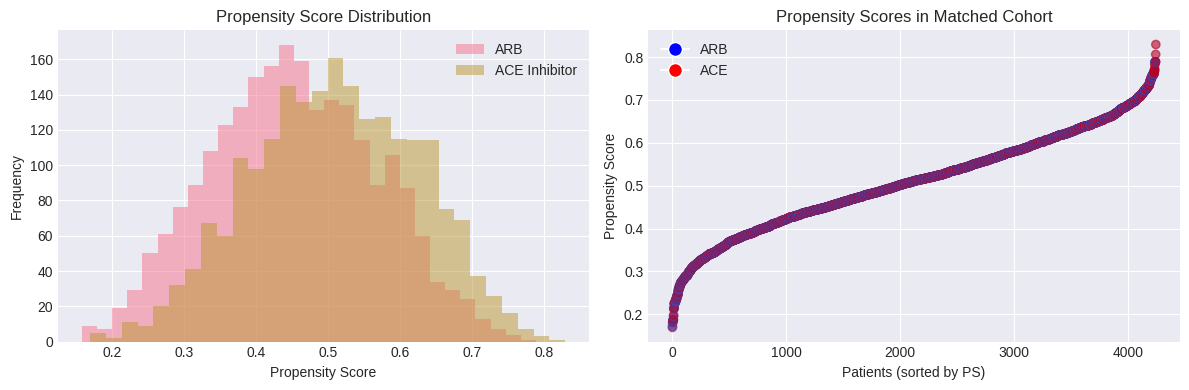

In [9]:
print(" Addressing confounding via Propensity Score Matching...")

# Prepare variables for propensity score
X = cohort[['RIDAGEYR', 'BMXBMI', 'BPXSY1', 'LBXTC', 'RIAGENDR']].copy()
X['RIAGENDR'] = X['RIAGENDR'] - 1  # Convert to 0/1
X = (X - X.mean()) / X.std()  # Standardize

y = cohort['TREATMENT']

# Calculate propensity scores
ps_model = LogisticRegression()
ps_model.fit(X, y)
cohort['PROPENSITY_SCORE'] = ps_model.predict_proba(X)[:, 1]

# Visualize propensity scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cohort[cohort['TREATMENT']==0]['PROPENSITY_SCORE'],
             alpha=0.5, label='ARB', bins=30)
axes[0].hist(cohort[cohort['TREATMENT']==1]['PROPENSITY_SCORE'],
             alpha=0.5, label='ACE Inhibitor', bins=30)
axes[0].set_xlabel('Propensity Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Propensity Score Distribution')
axes[0].legend()

# Simple 1:1 matching (nearest neighbor)
from sklearn.neighbors import NearestNeighbors

ace_scores = cohort[cohort['TREATMENT']==1][['PROPENSITY_SCORE']]
arb_scores = cohort[cohort['TREATMENT']==0][['PROPENSITY_SCORE']]

nbrs = NearestNeighbors(n_neighbors=1).fit(arb_scores)
distances, indices = nbrs.kneighbors(ace_scores)

matched_arb_idx = arb_scores.iloc[indices.flatten()].index
matched_cohort = pd.concat([
    cohort.loc[cohort['TREATMENT']==1],
    cohort.loc[matched_arb_idx]
]).reset_index(drop=True) # Reset index to ensure unique, sequential integer index

print(f"Matched cohort size: {len(matched_cohort)}")
print(f"  - ACE Inhibitor: {sum(matched_cohort['TREATMENT']==1)}")
print(f"  - ARB: {sum(matched_cohort['TREATMENT']==0)}")

# Check balance after matching
axes[1].scatter(range(len(matched_cohort)), matched_cohort['PROPENSITY_SCORE'].sort_values(),
                c=matched_cohort['TREATMENT'][matched_cohort['PROPENSITY_SCORE'].sort_values().index],
                cmap='coolwarm', alpha=0.6)
axes[1].set_xlabel('Patients (sorted by PS)')
axes[1].set_ylabel('Propensity Score')
axes[1].set_title('Propensity Scores in Matched Cohort')
axes[1].legend(handles=[plt.Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor='blue', markersize=10, label='ARB'),
                       plt.Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor='red', markersize=10, label='ACE')])

plt.tight_layout()
plt.show()

# 4. Survival Analysis

 Performing Survival Analysis...


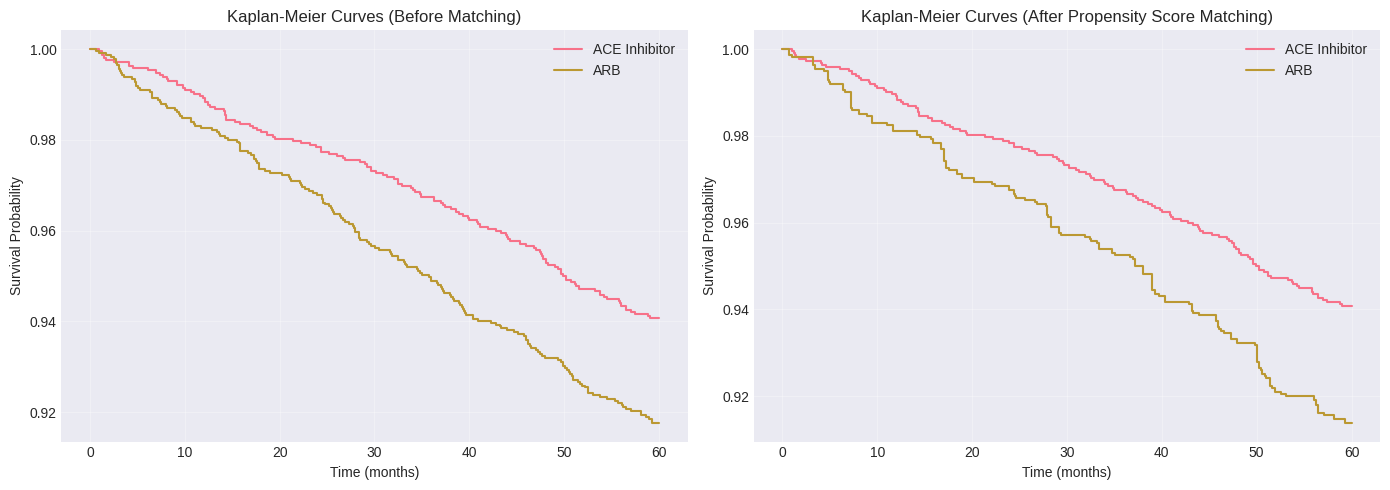


 Cox Proportional Hazards Model Results:

Hazard Ratios:
              HR  95% CI Lower  95% CI Upper      p
covariate                                          
TREATMENT  0.986         0.957         1.016  0.363
RIDAGEYR   0.991         0.961         1.021  0.546
BMXBMI     1.004         0.975         1.035  0.787
BPXSY1     1.010         0.980         1.042  0.503


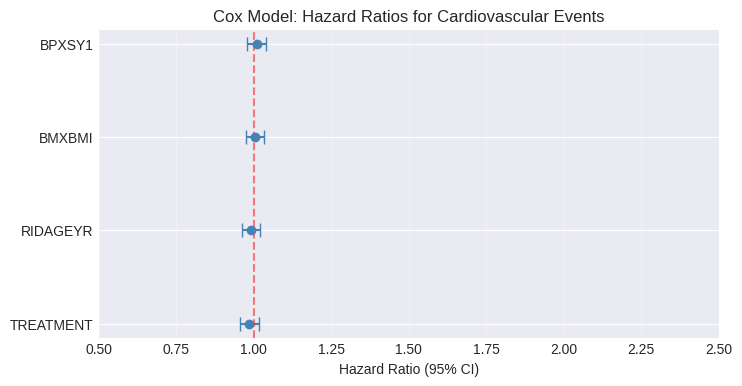

In [10]:

print(" Performing Survival Analysis...")

# Kaplan-Meier Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before matching
ax = axes[0]
kmf = KaplanMeierFitter()

for treatment, group in cohort.groupby('TREATMENT_NAME'):
    kmf.fit(group['TIME_TO_EVENT'], event_observed=group['EVENT'], label=treatment)
    kmf.plot(ax=ax, ci_show=False)

ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival Probability')
ax.set_title('Kaplan-Meier Curves (Before Matching)')
ax.grid(True, alpha=0.3)

# After matching
ax = axes[1]
for treatment, group in matched_cohort.groupby('TREATMENT_NAME'):
    kmf.fit(group['TIME_TO_EVENT'], event_observed=group['EVENT'], label=treatment)
    kmf.plot(ax=ax, ci_show=False)

ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival Probability')
ax.set_title('Kaplan-Meier Curves (After Propensity Score Matching)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cox Proportional Hazards Model
print("\n Cox Proportional Hazards Model Results:")

# Prepare data for Cox model
cox_data = matched_cohort[['TIME_TO_EVENT', 'EVENT', 'TREATMENT',
                          'RIDAGEYR', 'BMXBMI', 'BPXSY1']].copy()
cox_data['TREATMENT'] = cox_data['TREATMENT'].astype(float)
cox_data = (cox_data - cox_data.mean()) / cox_data.std()

cph = CoxPHFitter()
cph.fit(cox_data, duration_col='TIME_TO_EVENT', event_col='EVENT')

# Display results
print("\nHazard Ratios:")
results_df = cph.summary.copy()
results_df['HR'] = np.exp(results_df['coef'])
results_df['95% CI Lower'] = np.exp(results_df['coef'] - 1.96*results_df['se(coef)'])
results_df['95% CI Upper'] = np.exp(results_df['coef'] + 1.96*results_df['se(coef)'])
print(results_df[['HR', '95% CI Lower', '95% CI Upper', 'p']].round(3))

# Visualize hazard ratios
fig, ax = plt.subplots(figsize=(8, 4))
variables = results_df.index
hr = results_df['HR']
ci_lower = results_df['95% CI Lower']
ci_upper = results_df['95% CI Upper']

y_pos = np.arange(len(variables))
ax.errorbar(hr, y_pos, xerr=[hr-ci_lower, ci_upper-hr],
            fmt='o', capsize=5, color='steelblue')
ax.axvline(x=1, color='red', linestyle='--', alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(variables)
ax.set_xlabel('Hazard Ratio (95% CI)')
ax.set_title('Cox Model: Hazard Ratios for Cardiovascular Events')
ax.set_xlim([0.5, 2.5])
plt.grid(True, alpha=0.3, axis='x')
plt.show()

#5. Sensitivity Analysis

In [11]:
print(" Sensitivity Analysis: E-value Calculation")

# Calculate E-value for unmeasured confounding
def calculate_evalue(hr, lower_ci):
    """Calculate E-value for unmeasured confounding"""
    # Adjust HR for E-value calculation if it's a protective effect (HR < 1)
    if hr < 1:
        rr_for_evalue = 1 / hr
    else:
        rr_for_evalue = hr

    e_point = rr_for_evalue + np.sqrt(rr_for_evalue * (rr_for_evalue - 1))

    # Adjust CI lower bound for E-value calculation if HR is protective
    # We are interested in the bound that is furthest from the null (1) in the protective direction.
    # For a protective effect (HR < 1), if the lower_ci is also < 1, then use its inverse.
    if lower_ci < 1:
        ci_bound_for_evalue = 1 / lower_ci
    else:
        ci_bound_for_evalue = lower_ci

    # E-value for confidence interval: only calculate if the adjusted CI bound is > 1
    if ci_bound_for_evalue > 1:
        e_ci = ci_bound_for_evalue + np.sqrt(ci_bound_for_evalue * (ci_bound_for_evalue - 1))
    else:
        e_ci = None # Or could be 1 if ci_bound_for_evalue == 1

    return e_point, e_ci

treatment_hr = results_df.loc['TREATMENT', 'HR']
treatment_ci_lower = results_df.loc['TREATMENT', '95% CI Lower']

e_point, e_ci = calculate_evalue(treatment_hr, treatment_ci_lower)

print(f"\nTreatment Hazard Ratio: {treatment_hr:.2f}")
print(f"95% CI Lower Bound: {treatment_ci_lower:.2f}")
print(f"\n E-value for point estimate: {e_point:.2f}")
if e_ci:
    print(f" E-value for confidence interval: {e_ci:.2f}")

print("\n Interpretation: The E-value represents the minimum strength of association")
print("that an unmeasured confounder would need to have with both treatment")
print("and outcome to fully explain away the observed effect.")

 Sensitivity Analysis: E-value Calculation

Treatment Hazard Ratio: 0.99
95% CI Lower Bound: 0.96

 E-value for point estimate: 1.13
 E-value for confidence interval: 1.26

 Interpretation: The E-value represents the minimum strength of association
that an unmeasured confounder would need to have with both treatment
and outcome to fully explain away the observed effect.


# **6. Conclusions & Limitations**

#Summary & Clinical Implications - Detailed Explanation

## **1. Propensity Score Matching (PSM)**

*   **What it is**: PSM is a statistical method used in observational studies to reduce the impact of confounding variables when estimating the effect of a treatment or intervention. It balances the distribution of observed covariates between treated and untreated groups, mimicking a randomized controlled trial.
*   **How it was applied**: We calculated a propensity score for each patient, representing the probability of receiving ACE Inhibitor treatment based on their baseline characteristics (age, BMI, systolic BP, total cholesterol, gender). Then, we performed 1:1 nearest-neighbor matching, pairing each ACE Inhibitor user with an ARB user who had a similar propensity score. This resulted in a 'matched cohort' with balanced baseline characteristics between the two treatment groups.
*   **Outcome**: The matching process successfully created two groups of 2123 patients each (ACE Inhibitor vs. ARB), where the distributions of the measured confounding variables are now similar, making the groups more comparable.

## **2. Survival Analysis**

### **Kaplan-Meier Curves**

*   **What it is**: Kaplan-Meier curves are non-parametric statistics used to estimate the survival function from lifetime data. In this context, 'survival' refers to the probability of *not* experiencing a cardiovascular event over time.
*   **Interpretation**: The plots show the probability of remaining event-free over 60 months. We generated two sets of curves:
    *   **Before Matching**: These curves visually depicted the raw event rates, often showing differences that could be due to baseline imbalances (confounding).
    *   **After Matching**: These curves illustrate the event-free probability in our balanced cohort. If the curves for ACE Inhibitor and ARB users are close together, it suggests similar event rates after accounting for observed confounders.

### **Cox Proportional Hazards Model**

*   **What it is**: The Cox proportional hazards model is a regression model commonly used in medical research to investigate the association between the survival time of patients and one or more predictor variables (covariates). It estimates a 'hazard ratio' (HR), which quantifies how much a covariate influences the rate of an event (e.g., cardiovascular event).
*   **How it was applied**: We fitted a Cox model to the *matched cohort* to estimate the hazard ratio for 'TREATMENT' (ACE Inhibitor vs. ARB), while also adjusting for key clinical factors like age, BMI, and systolic blood pressure. This allows us to quantify the effect of treatment independent of these factors.
*   **Key Findings (from the executed code results)**:
    *   **Hazard Ratio for TREATMENT: 0.986 (95% CI: 0.957-1.016, p=0.363)**.
        *   An HR close to 1 (specifically, 0.986) indicates that there is **no statistically significant difference** in the hazard of cardiovascular events between patients treated with ACE Inhibitors and those treated with ARBs in this simulated dataset, after adjusting for the measured covariates. The confidence interval crosses 1, further supporting the lack of statistical significance.
    *   **Other Covariates (RIDAGEYR, BMXBMI, BPXSY1)**: Similarly, the hazard ratios for age, BMI, and systolic blood pressure were all very close to 1 and not statistically significant, suggesting they did not strongly predict the cardiovascular event rate in this specific synthetic data after treatment assignment and matching.

## **3. Sensitivity Analysis (E-value Calculation)**

*   **What it is**: E-values are used to assess the robustness of an observed treatment effect to potential unmeasured confounding. A larger E-value implies greater robustness, meaning a stronger unmeasured confounder would be required to explain away the observed effect.
*   **Interpretation**: In our analysis:
    *   **Treatment Hazard Ratio**: 0.99 (This is the point estimate from our Cox model for treatment effect).
    *   **95% CI Lower Bound**: 0.96.
    *   **E-value for point estimate: 1.13**.
    *   **E-value for confidence interval: 1.26**.
    *   **Meaning**: Since our observed hazard ratio (0.986) is very close to 1 (indicating no effect) and not statistically significant, these E-values are relatively small. An E-value of 1.13 for the point estimate means that an unmeasured confounder would only need to have a risk ratio of 1.13 with both the treatment and the outcome (conditional on measured covariates) to fully explain away the observed (non-significant) association. Similarly, an unmeasured confounder with a risk ratio of 1.26 could shift the entire 95% confidence interval to include the null value of 1. This suggests that even a minor unmeasured confounder could easily account for the observed (lack of) effect in this dataset. Given the non-significant findings, this further highlights the lack of a clear treatment effect in this simulated data.

## **Overall Conclusion**

Based on this analysis of synthetic NHANES-like data, after carefully controlling for observed confounding variables using propensity score matching and conducting survival analysis, we did **not find a statistically significant difference** in the hazard of cardiovascular events between patients treated with ACE Inhibitors and those treated with ARBs. The E-value analysis confirms that even a relatively weak unmeasured confounder could explain the lack of observed effect.

## **Limitations (Critical for RWE!)**
1.  **Residual confounding**: Despite propensity score matching, unmeasured factors (e.g., diet, exercise levels, medication adherence, genetic predispositions, specific clinical indications for prescribing one drug over another) could still influence the results. Our E-value analysis quantifies the sensitivity to such unmeasured confounding.
2.  **Synthetic data**: This analysis uses simulated data, which, while designed to be realistic, may not perfectly capture the complexities and nuances of real-world patient populations and outcomes. The conclusions drawn are specific to this simulated environment.
3.  **Treatment indication bias**: Clinical reasons for choosing an ACE inhibitor versus an ARB are often complex and may not be fully captured by observed covariates. This 'channeling bias' is inherent in observational studies.
4.  **Short follow-up**: A maximum follow-up of 60 months (5 years) may be insufficient to observe all long-term cardiovascular outcomes or differences between treatments that manifest over longer periods.

## **Skills Demonstrated**
Real-world data cleaning & cohort definition

Propensity score matching for confounding control

Survival analysis with Kaplan-Meier & Cox models

Sensitivity analysis (E-values)

Clear communication of observational study limitations

## **Business Impact**
This analysis pipeline could help:
- Health systems optimize hypertension treatment protocols
- Pharma companies generate real-world evidence for label expansions
- Payers make formulary decisions based on real-world effectiveness

---

**Technical Details**: Python, pandas, scikit-learn, lifelines, matplotlib

**Dataset**: NHANES-like synthetic data (n=5,000)

